In [1]:
from common import *

In [2]:
import torch
import matplotlib.pyplot as plt

In [3]:
ckpt_path = "./data/finetune-model.pt"
user_dir = "./library"
models, saved_cfg, task = checkpoint_utils.load_model_ensemble_and_task([ckpt_path])
models[0].encoder.w2v_model.encoder.layers[0].self_attn.out_proj.weight.data

/Users/shared/RAVE/Workspaces/haotian/avhubert/library/fairseq/fairseq/checkpoint_utils.py:304: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f, map_locat

tensor([[ 0.2751,  0.0517,  0.1427,  ...,  0.0168,  0.0568, -0.0168],
        [ 0.0158, -0.0943, -0.0148,  ...,  0.0320,  0.0732, -0.0129],
        [-0.0403, -0.1056, -0.1247,  ..., -0.0812,  0.0501, -0.0850],
        ...,
        [-0.0381, -0.0984,  0.1057,  ..., -0.0463,  0.0490,  0.0044],
        [-0.0236,  0.0361, -0.0998,  ...,  0.0628, -0.0010,  0.1583],
        [ 0.0578, -0.0647, -0.0163,  ..., -0.0759, -0.0394,  0.1151]])

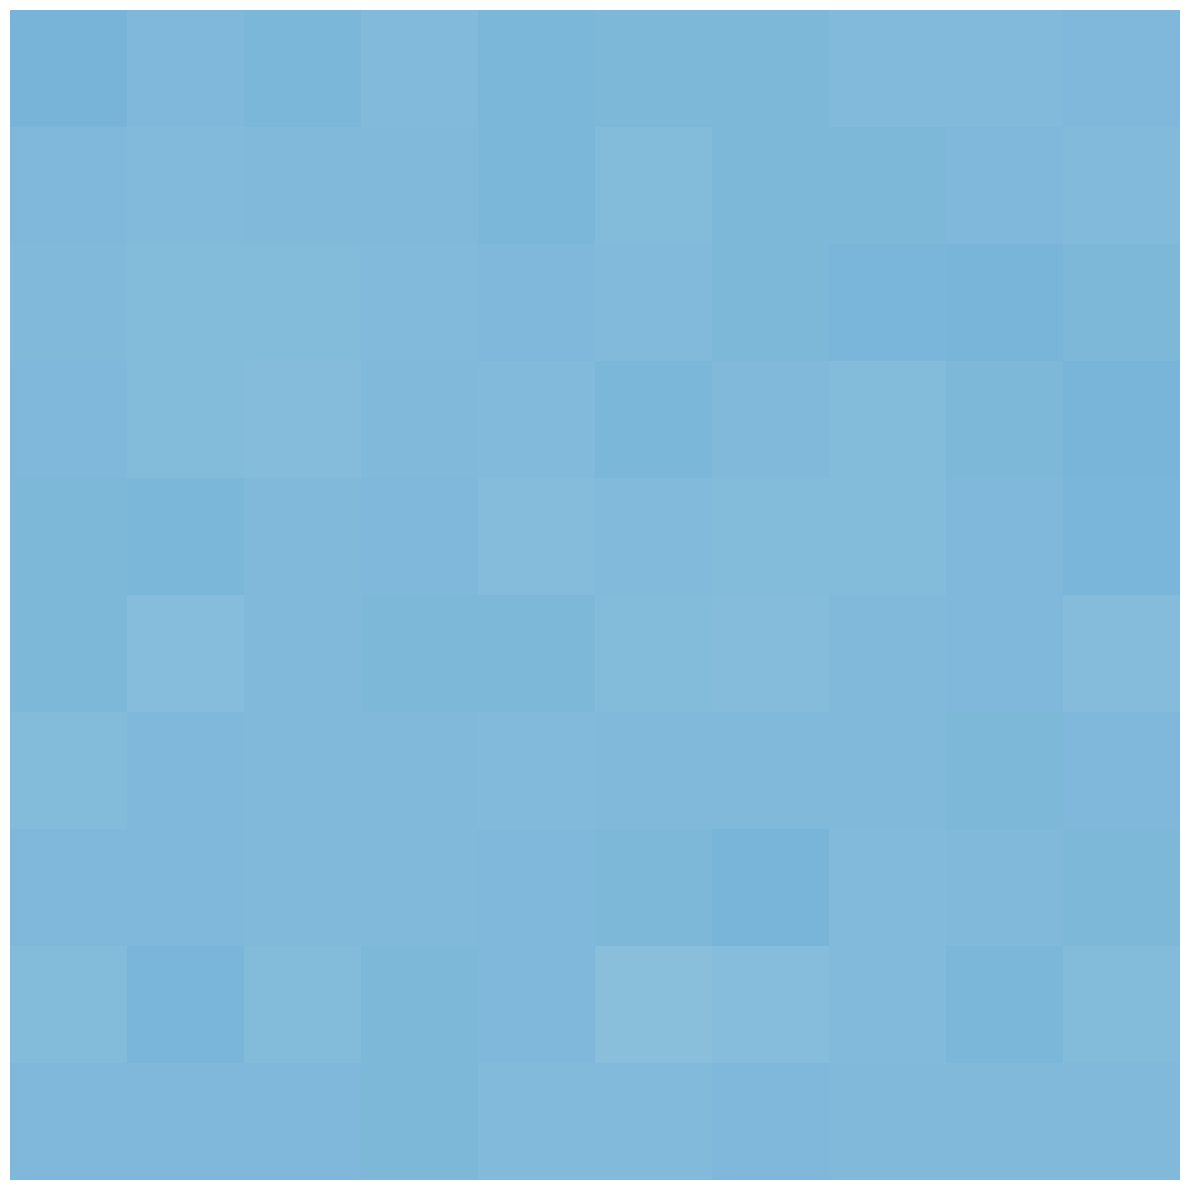

In [42]:
import matplotlib.pyplot as plt
import torch

with torch.no_grad():
    fig, ax = plt.subplots(figsize=(12, 12))  # only one subplot

    noise_shape = models[0].encoder.w2v_model.encoder.layers[0].self_attn.out_proj.weight.data.shape
    seed = 0 * 1000 + 0
    torch.manual_seed(seed)
    gaus_noise = torch.randn(noise_shape) * 0.1  # alpha = 0.1

    # Add noise to weight and crop
    weight = models[0].encoder.w2v_model.encoder.layers[0].self_attn.out_proj.weight.data.cpu()
    vmin = weight.min().item()
    vmax = weight.max().item()

    cropped_weight = weight[0:10, 0:10]
    
    im = ax.imshow(cropped_weight, aspect='equal', cmap='Blues', vmin=-6.1, vmax=7.5)
    ax.axis('off')  # hide axes

    plt.tight_layout()
    #plt.savefig("noisy_out_proj_weights_layers0_subject0.png", dpi=300)
    plt.show()

In [7]:
noise_shape = models[0].encoder.w2v_model.encoder.layers[0].self_attn.out_proj.weight.data.shape
seed = 0 * 1000 + 0
torch.manual_seed(seed)
gaus_noise = torch.randn(noise_shape) * 0.1  # alpha = 0.1

# Add noise to weight and crop
weight = models[0].encoder.w2v_model.encoder.layers[0].self_attn.out_proj.weight.data.cpu() + gaus_noise
vmin = weight[0:10, 0:10].min().item()
vmax = weight[0:10, 0:10].max().item()


In [9]:
import pickle
import torch

# Save the tensor to a file using pickle.dump()
with open('gaus_noise_AVH_l1.pkl', 'wb') as f:
    pickle.dump(gaus_noise, f)

In [75]:
weight[0:10,0:10] 

tensor([[ 0.1626, -0.0635,  0.1176, -0.0995,  0.2392,  0.1586,  0.0786, -0.2857,
         -0.0577, -0.0823],
        [-0.0926, -0.1072, -0.0829, -0.1223,  0.1827, -0.2754,  0.2695,  0.1286,
          0.0639, -0.0678],
        [ 0.0263, -0.0171, -0.0780, -0.1525,  0.0079, -0.1035, -0.0013,  0.1003,
          0.2021,  0.0616],
        [-0.1547, -0.1181, -0.1904,  0.0568, -0.2452,  0.1323, -0.0866, -0.1590,
         -0.0535,  0.0289],
        [ 0.2593,  0.2678, -0.0525,  0.0575, -0.0294, -0.0366,  0.0324, -0.1360,
         -0.0139,  0.1589],
        [ 0.0980, -0.2173, -0.1956, -0.1384,  0.1910, -0.1313, -0.1069, -0.0611,
          0.1038, -0.1852],
        [-0.0504,  0.1110,  0.0513, -0.1456, -0.1204,  0.0224, -0.0169,  0.1116,
          0.0890,  0.1697],
        [-0.0089, -0.0070,  0.0594, -0.0875,  0.1983, -0.0174,  0.3159,  0.0766,
         -0.0069, -0.0234],
        [-0.1061,  0.0978, -0.0027,  0.0572,  0.1080, -0.3450, -0.3686, -0.2365,
          0.2578, -0.2656],
        [-0.0299, -

In [73]:
weight[0:10,0:10] 

tensor([[ 0.2751,  0.0517,  0.1427, -0.0561,  0.1543,  0.0894,  0.1102, -0.0742,
         -0.0900,  0.0440],
        [ 0.0158, -0.0943, -0.0148,  0.0087,  0.1166, -0.1342,  0.0861,  0.0829,
          0.0364, -0.0877],
        [-0.0403, -0.1056, -0.1247, -0.0880,  0.0520, -0.0712,  0.0981,  0.1824,
          0.2341,  0.0926],
        [ 0.0571, -0.1104, -0.1707,  0.0012, -0.0869,  0.1230, -0.0154, -0.1140,
          0.0990,  0.2345],
        [ 0.0645,  0.1670, -0.0424,  0.0421, -0.1544, -0.0507, -0.1052, -0.1400,
          0.0300,  0.2001],
        [ 0.0627, -0.2041, -0.0317,  0.1063,  0.1031, -0.1031, -0.1552, -0.0293,
          0.0362, -0.1700],
        [-0.1357,  0.0275, -0.0245,  0.0074, -0.0756, -0.0056, -0.0042, -0.0073,
          0.0802,  0.0169],
        [ 0.0186,  0.0494, -0.0376, -0.0243,  0.0355,  0.0973,  0.2321, -0.0670,
         -0.0206,  0.0669],
        [-0.1326,  0.1769, -0.1008,  0.0746,  0.0178, -0.3247, -0.2297, -0.0608,
          0.1460, -0.1266],
        [ 0.0409,  

In [55]:
print(vmin,vmax)

-0.32470703125 0.275146484375


In [47]:
print(vmin,vmax)

-0.3686462640762329 0.315852552652359


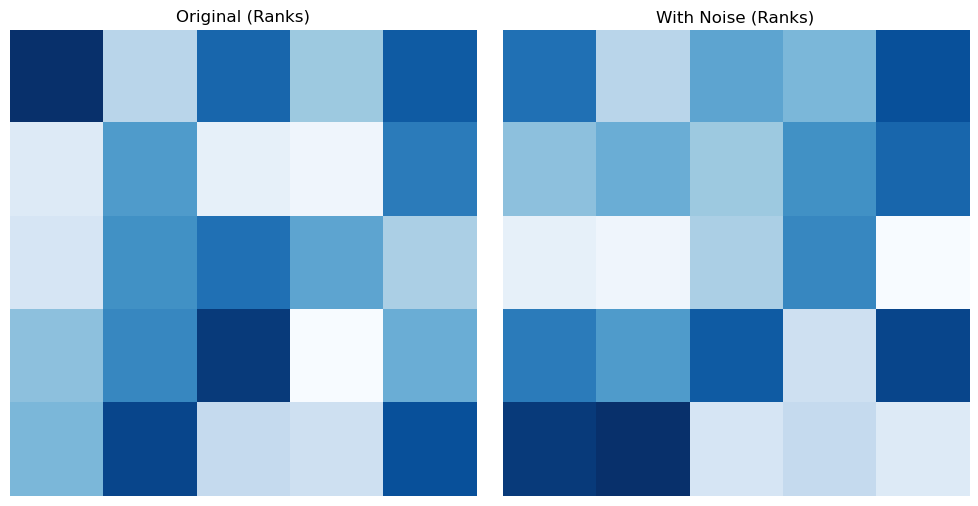

In [72]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from scipy.stats import rankdata

with torch.no_grad():
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Get weight and noise
    weight = models[0].encoder.w2v_model.encoder.layers[0].self_attn.out_proj.weight.data.cpu()
    noise_shape = weight.shape
    seed = 0 * 1000 + 0
    torch.manual_seed(seed)
    gaus_noise = torch.randn(noise_shape) * 0.1  # alpha = 0.1

    # Crop
    cropped_weight = weight[0:5, 0:5].numpy()
    cropped_weight1 = (weight + gaus_noise)[0:5, 0:5].numpy()

    # Convert to rank (smallest = 1, largest = 25)
    rank_original = rankdata(abs(cropped_weight), method='ordinal').reshape(cropped_weight.shape)
    rank_noisy = rankdata(abs(cropped_weight1), method='ordinal').reshape(cropped_weight1.shape)

    # Plot ranks
    axes[0].imshow(rank_original, aspect='equal', cmap='Blues')
    axes[0].axis('off')
    axes[0].set_title("Original (Ranks)")

    axes[1].imshow(rank_noisy, aspect='equal', cmap='Blues')
    axes[1].axis('off')
    axes[1].set_title("With Noise (Ranks)")

    plt.tight_layout()
    plt.savefig("out_proj_weights_5x5_ranked.png", dpi=300)
    plt.show()


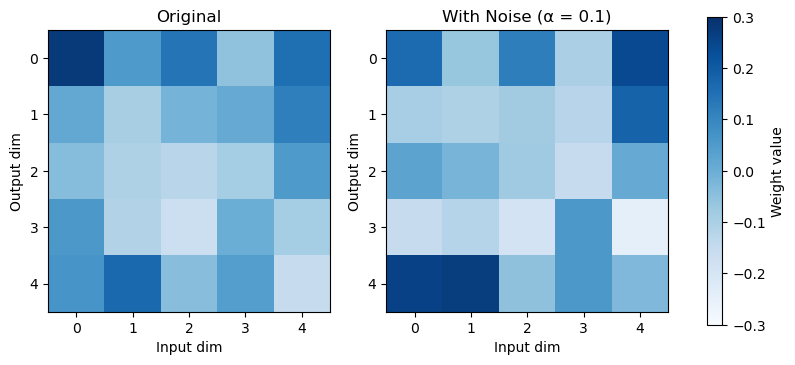

In [86]:
import matplotlib.pyplot as plt
import torch

with torch.no_grad():
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # Two plots side-by-side

    # Get weight and noise
    weight = models[0].encoder.w2v_model.encoder.layers[0].self_attn.out_proj.weight.data.cpu()
    noise_shape = weight.shape
    seed = 0 * 1000 + 0
    torch.manual_seed(seed)
    gaus_noise = torch.randn(noise_shape) * 0.1  # alpha = 0.1

    # Crop
    cropped_weight = weight[0:5, 0:5]
    cropped_weight1 = cropped_weight + gaus_noise[0:5, 0:5]

    vmin, vmax = -0.3, 0.3

    # Plot original
    im0 = axes[0].imshow(cropped_weight, aspect='equal', cmap='Blues', vmin=vmin, vmax=vmax)
    axes[0].set_title("Original")
    axes[0].set_xlabel("Input dim")
    axes[0].set_ylabel("Output dim")

    # Plot with noise
    im1 = axes[1].imshow(cropped_weight1, aspect='equal', cmap='Blues', vmin=vmin, vmax=vmax)
    axes[1].set_title("With Noise (α = 0.1)")
    axes[1].set_xlabel("Input dim")
    axes[1].set_ylabel("Output dim")

    # Add shared colorbar to the right, not on top
    cbar = fig.colorbar(im1, ax=axes, location='right', shrink=0.8, pad=0.05)
    cbar.set_label("Weight value")

    plt.savefig("out_proj_weights_5by5_layer0_clean_colormap.png", dpi=300)
    plt.show()


/var/folders/jx/t6p8dp8j3_98g_gs99jtrv_h0000gn/T/ipykernel_54143/890371951.py:28: UserWarning: Adding colorbar to a different Figure <Figure size 1200x1200 with 1 Axes> than <Figure size 1000x500 with 3 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
/var/folders/jx/t6p8dp8j3_98g_gs99jtrv_h0000gn/T/ipykernel_54143/890371951.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


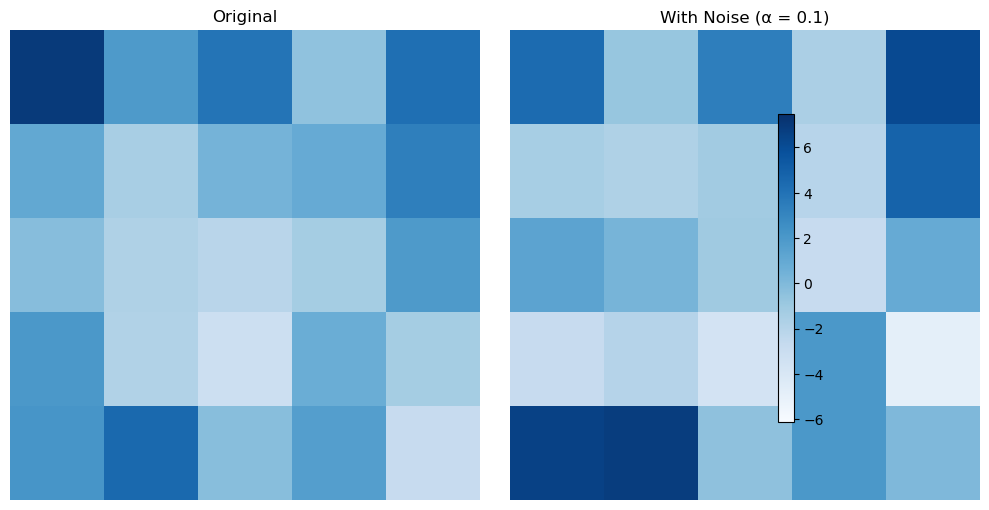

In [83]:
import matplotlib.pyplot as plt
import torch

with torch.no_grad():
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # Two plots side-by-side

    # Get weight and noise
    weight = models[0].encoder.w2v_model.encoder.layers[0].self_attn.out_proj.weight.data.cpu()
    noise_shape = weight.shape
    seed = 0 * 1000 + 0
    torch.manual_seed(seed)
    gaus_noise = torch.randn(noise_shape) * 0.1  # alpha = 0.1

    # Crop
    cropped_weight = weight[0:5, 0:5]
    cropped_weight1 = cropped_weight + gaus_noise[0:5, 0:5]

    # Plot original
    axes[0].imshow(cropped_weight, aspect='equal', cmap='Blues', vmin=-0.3, vmax=0.3)
    axes[0].axis('off')
    axes[0].set_title("Original")

    # Plot with noise
    axes[1].imshow(cropped_weight1, aspect='equal', cmap='Blues', vmin=-0.3, vmax=0.3)
    axes[1].axis('off')
    axes[1].set_title("With Noise (α = 0.1)")

    plt.tight_layout()
    plt.savefig("out_proj_weights_5by5_layers0_original_vs_noisy.png", dpi=300)  # save figure
    plt.show()




In [77]:
    plt.colorbar(im, ax=axes)

/var/folders/jx/t6p8dp8j3_98g_gs99jtrv_h0000gn/T/ipykernel_54143/3803833870.py:1: UserWarning: Adding colorbar to a different Figure <Figure size 1200x1200 with 1 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=axes)


<Figure size 640x480 with 0 Axes>

In [67]:
np.quantile(abs(weight), 0.99)

0.301513671875

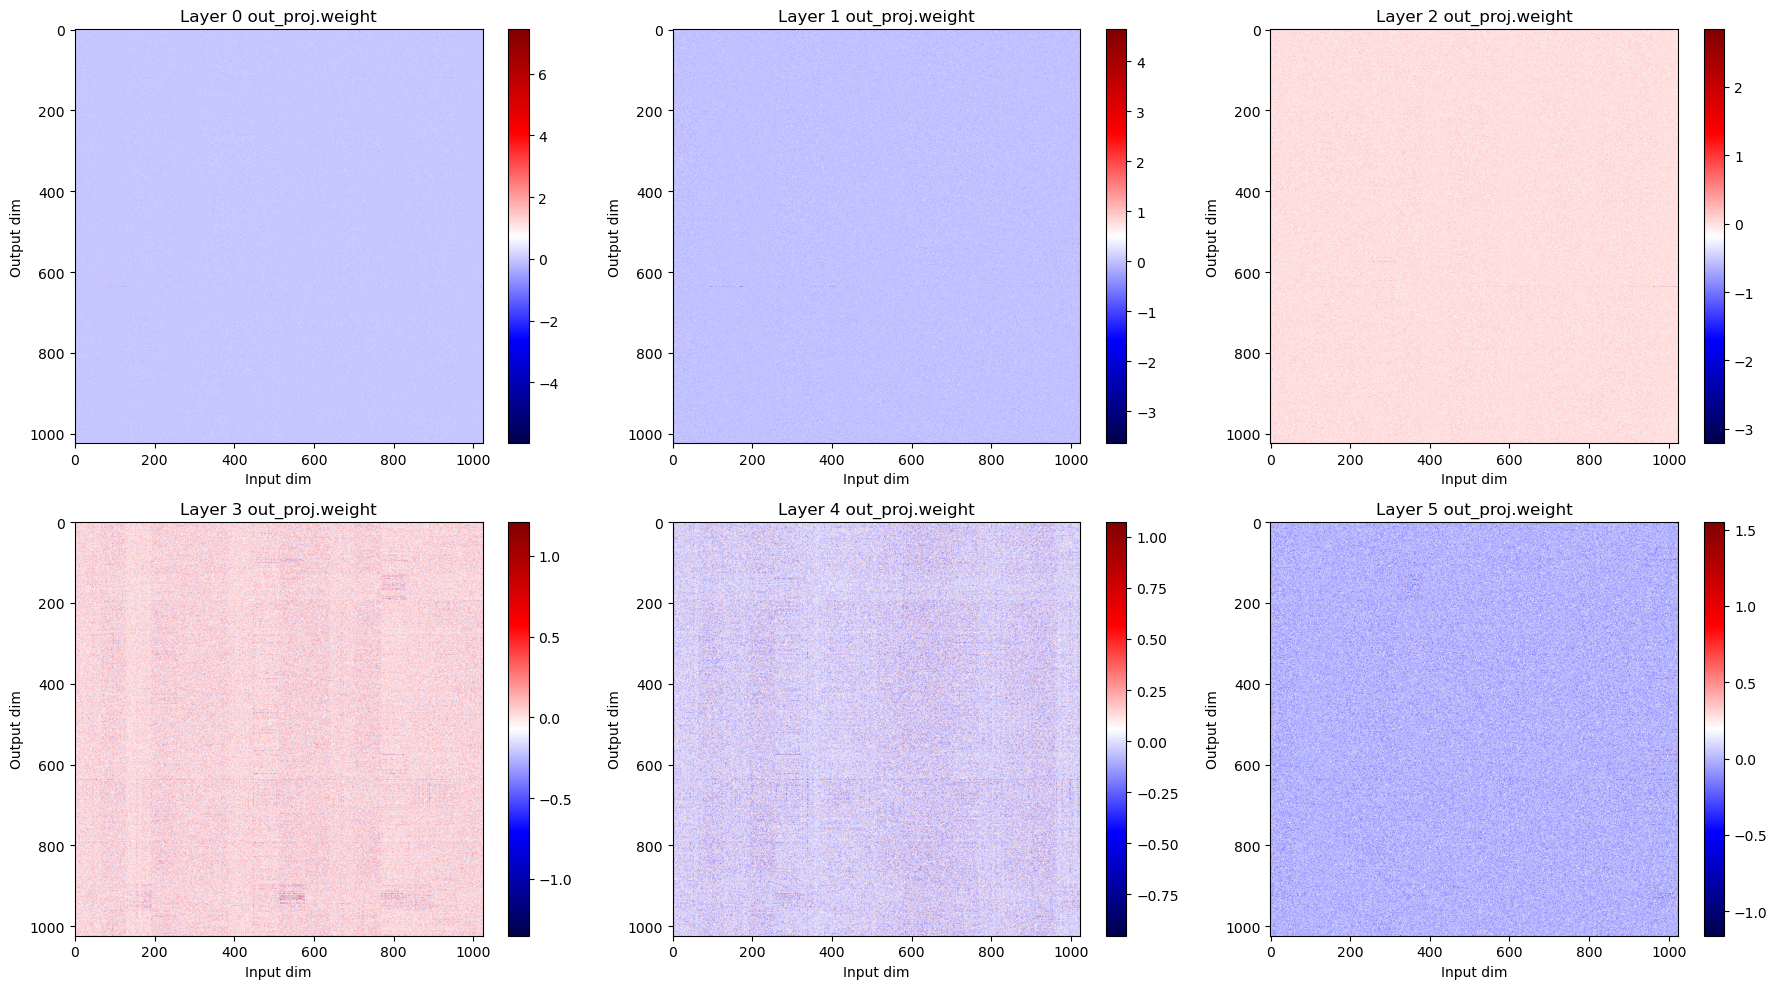

In [5]:
with torch.no_grad():
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i in range(6):  # layers 0 through 5
        weight = models[0].encoder.w2v_model.encoder.layers[i].self_attn.out_proj.weight.data.cpu()

        vmin = weight.min().item()
        vmax = weight.max().item()

        im = axes[i].imshow(weight, aspect='auto', cmap='seismic', vmin=vmin, vmax=vmax)
        axes[i].set_title(f"Layer {i} out_proj.weight")
        axes[i].set_xlabel("Input dim")
        axes[i].set_ylabel("Output dim")
        plt.colorbar(im, ax=axes[i])

    plt.tight_layout()
    
    plt.show()




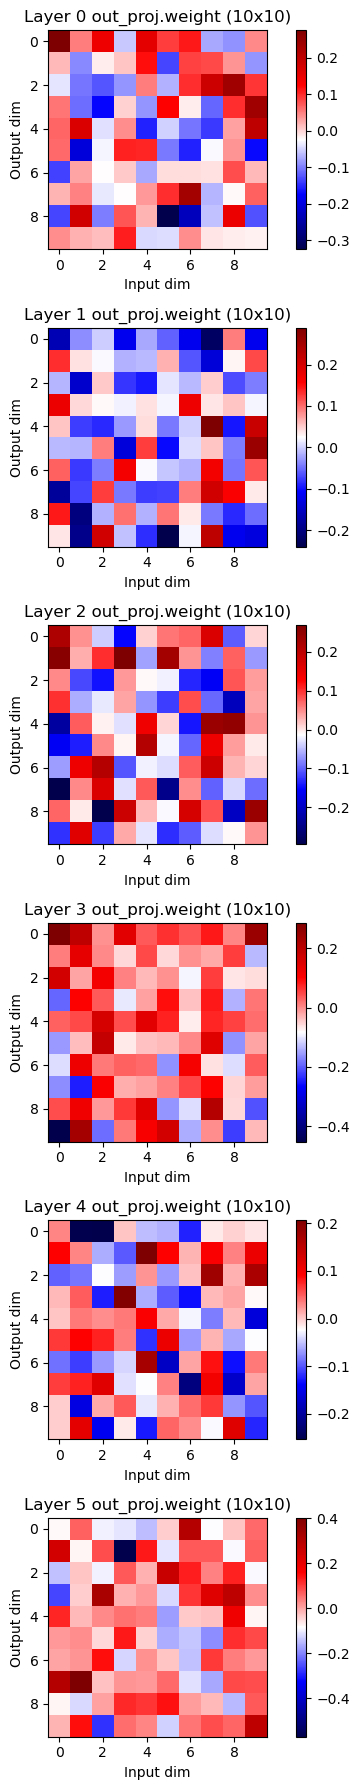

In [46]:
with torch.no_grad():
    fig, axes = plt.subplots(6, 1, figsize=(6, 18))  # 6 rows, 1 column
    axes = axes.flatten()

    for i in range(6):  # layers 0 through 5
        weight = models[0].encoder.w2v_model.encoder.layers[i].self_attn.out_proj.weight.data.cpu()
        cropped_weight = weight[0:10, 0:10]  # only plot this region

        vmin = cropped_weight.min().item()
        vmax = cropped_weight.max().item()

        im = axes[i].imshow(cropped_weight, aspect='equal', cmap='seismic', vmin=vmin, vmax=vmax)
        axes[i].set_title(f"Layer {i} out_proj.weight (10x10)")
        axes[i].set_xlabel("Input dim")
        axes[i].set_ylabel("Output dim")
        plt.colorbar(im, ax=axes[i])

    plt.tight_layout()
    plt.savefig("out_proj_weights_10x10_layers0to5_original.png", dpi=300)  # save figure
    plt.show()


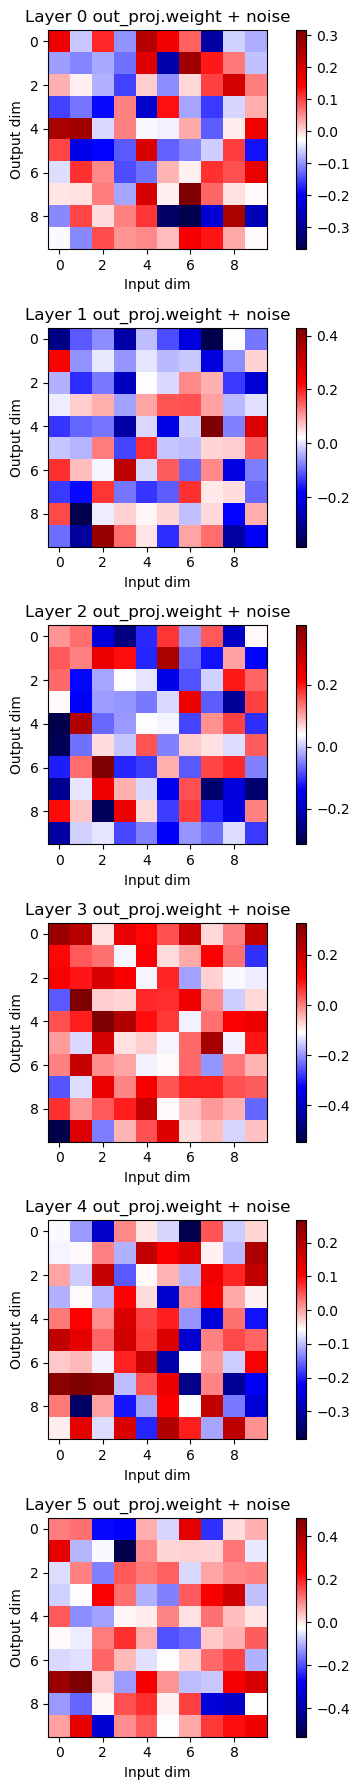

In [51]:
import torch
import matplotlib.pyplot as plt

with torch.no_grad():
    fig, axes = plt.subplots(6, 1, figsize=(6, 18))  # 6 rows, 1 column
    axes = axes.flatten()

    for i in range(6):  # layers 0 through 5
        noise_shape = models[0].encoder.w2v_model.encoder.layers[0].self_attn.out_proj.weight.data.shape
        seed = 0 * 1000 + i
        torch.manual_seed(seed)
        gaus_noise = torch.randn(noise_shape) * 0.1  # alpha = 0.1

        # Add noise to weight and crop
        weight = models[0].encoder.w2v_model.encoder.layers[i].self_attn.out_proj.weight.data.cpu() + gaus_noise
        cropped_weight = weight[0:10, 0:10]

        vmin = cropped_weight.min().item()
        vmax = cropped_weight.max().item()

        im = axes[i].imshow(cropped_weight, aspect='equal', cmap='seismic', vmin=vmin, vmax=vmax)
        axes[i].set_title(f"Layer {i} out_proj.weight + noise")
        axes[i].set_xlabel("Input dim")
        axes[i].set_ylabel("Output dim")
        plt.colorbar(im, ax=axes[i])

    plt.tight_layout()
    plt.savefig("noisy_out_proj_weights_layers0to5_subject0.png", dpi=300)
    plt.show()
